# Classification of Skin Lesions using ResNet-34 

**Date:** 8 March, 2026  
**Authors:** Sarvan Kumar (ME23B1065),Rohit Kumar (CS23B2053)

---

## Lab Assignment Objectives

In this lab assignment, we implement:
1. **ResNet-34** - Built from scratch using basic PyTorch layers

### Dataset
- **ISIC 2019 Skin Lesion Dataset**
- 8 diagnostic classes: MEL, NV, BCC, AK, BKL, DF, VASC, SCC
- Training: 25,331 images | Test: 8,238 images

### Requirements
###### Custom dataset class for loading ISIC data  
###### Build ResNet-34 from scratch (no prebuilt architecture)  
###### Verify model parameters match standard architecture  
###### Experiment with hyperparameters and document observations  
###### Comprehensive evaluation metrics: AUC-ROC, Accuracy, Balanced Accuracy, Sensitivity, Specificity, F1, Precision, Cohen's Kappa, Confusion Matrix  
###### Summarize observations and learnings

## 1. Environment Setup and Library Imports

In [1]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
import cv2
from tqdm.auto import tqdm
from itertools import cycle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score, cohen_kappa_score, 
                             confusion_matrix, roc_curve, auc, classification_report)
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

# Prevents crashes from corrupted images
ImageFile.LOAD_TRUNCATED_IMAGES = True 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Compute Engine Enabled: {device}")

base_dir = './isic_data'
train_csv_path = os.path.join(base_dir, 'ISIC_2019_Training_GroundTruth.csv')
test_csv_path = os.path.join(base_dir, 'ISIC_2019_Test_GroundTruth.csv')

df_full_train = pd.read_csv(train_csv_path)
df_full_test = pd.read_csv(test_csv_path)

if 'UNK' in df_full_train.columns:
    df_full_train = df_full_train[df_full_train['UNK'] == 0.0].reset_index(drop=True)
if 'UNK' in df_full_test.columns:
    df_full_test = df_full_test[df_full_test['UNK'] == 0.0].reset_index(drop=True)

class_names = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
NUM_CLASSES = len(class_names)

df_train, df_val = train_test_split(df_full_train, test_size=0.20, random_state=42, stratify=df_full_train[class_names])
print("Data mapping and splitting complete.")

Compute Engine Enabled: cuda
Data mapping and splitting complete.


## 2. Preprocessing: Hair Removal using DullRazor Algorithm


In [2]:
def apply_hair_removal(image):
    img_cv = np.array(image)
    img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)
    grayScale = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (17, 17))
    blackhat = cv2.morphologyEx(grayScale, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    
    inpainted_img = cv2.inpaint(img_cv, mask, 1, cv2.INPAINT_TELEA)
    inpainted_img = cv2.cvtColor(inpainted_img, cv2.COLOR_BGR2RGB)
    return Image.fromarray(inpainted_img)

train_img_dir = os.path.join(base_dir, 'ISIC_2019_Training_Input')
test_img_dir = os.path.join(base_dir, 'ISIC_2019_Test_Input')

clean_train_dir = os.path.join(base_dir, 'ISIC_2019_Training_Cleaned')
clean_test_dir = os.path.join(base_dir, 'ISIC_2019_Test_Cleaned')

os.makedirs(clean_train_dir, exist_ok=True)
os.makedirs(clean_test_dir, exist_ok=True)

print("Checking for pre-cleaned images...")

train_files = [f for f in os.listdir(train_img_dir) if f.endswith('.jpg')]
for img_name in tqdm(train_files, desc="Cleaning Train/Val"):
    src, dest = os.path.join(train_img_dir, img_name), os.path.join(clean_train_dir, img_name)
    if not os.path.exists(dest):
        try: apply_hair_removal(Image.open(src).convert('RGB')).save(dest)
        except: pass

test_files = [f for f in os.listdir(test_img_dir) if f.endswith('.jpg')]
for img_name in tqdm(test_files, desc="Cleaning Test"):
    src, dest = os.path.join(test_img_dir, img_name), os.path.join(clean_test_dir, img_name)
    if not os.path.exists(dest):
        try: apply_hair_removal(Image.open(src).convert('RGB')).save(dest)
        except: pass

print("Offline Preprocessing Complete!")

Checking for pre-cleaned images...


Cleaning Train/Val:   0%|          | 0/25331 [00:00<?, ?it/s]

Cleaning Test:   0%|          | 0/8238 [00:00<?, ?it/s]

Offline Preprocessing Complete!


## 3. Dataset Loading and Preparation

In [3]:
class ISICDatasetFast(Dataset):
    def __init__(self, df, img_dir, class_names, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.class_names = class_names
        self.transform = transform

    def __len__(self): 
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'image'] + '.jpg'
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
            
        if self.transform: 
            image = self.transform(image)
            
        label = np.argmax(self.df.loc[idx, self.class_names].values.astype('float32'))
        return image, label

# Added your required dropout variable here
CONFIG = {"batch_size": 32, "epochs": 35, "img_size": 224, "dropout": 0.4}

class_counts = df_train[class_names].sum().values
class_weights = 1.0 / class_counts
sample_weights = [class_weights[np.argmax(df_train.iloc[i][class_names].values)] for i in range(len(df_train))]
sample_weights = torch.DoubleTensor(sample_weights)

imbalance_sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomAffine(degrees=90, translate=(0.1, 0.1), scale=(0.8, 1.2)), 
    transforms.ColorJitter(brightness=0.1, contrast=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

eval_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

train_loader = DataLoader(ISICDatasetFast(df_train, clean_train_dir, class_names, train_transform), 
                          batch_size=CONFIG["batch_size"], sampler=imbalance_sampler)

val_loader = DataLoader(ISICDatasetFast(df_val, clean_train_dir, class_names, eval_transform), 
                        batch_size=CONFIG["batch_size"], shuffle=False)

test_loader = DataLoader(ISICDatasetFast(df_full_test, clean_test_dir, class_names, eval_transform), 
                         batch_size=CONFIG["batch_size"], shuffle=False)

print("High-Speed Loaders initialized!")

High-Speed Loaders initialized!


## 4. ResNet-34 Architecture (Built from Scratch)

In [4]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return torch.relu(out)

class ResNet34Scratch(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=CONFIG["dropout"]):
        super(ResNet34Scratch, self).__init__()
        self.in_planes = 64
        
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(BasicBlock, 64, 3, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 4, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 6, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 3, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.maxpool(torch.relu(self.bn1(self.conv1(x))))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        return self.fc(self.dropout(out))

model_scratch34 = ResNet34Scratch().to(device)
print(f"Your Custom Architecture ResNet-34 Deployed and moved to GPU.")

Your Custom Architecture ResNet-34 Deployed and moved to GPU.


## 5. Model Training

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model_scratch34.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

history_scratch = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float('inf')
model_save_path_scratch34 = './resnet34_user_scratch_best.pth'

print("Beginning Full-Network Training from Scratch...")

for epoch in range(CONFIG["epochs"]):
    model_scratch34.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_scratch34(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
        correct_train += (outputs.argmax(1) == labels).sum().item()
        total_train += labels.size(0)
        
    model_scratch34.eval()
    val_loss, correct_val = 0.0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model_scratch34(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            correct_val += (outputs.argmax(1) == labels).sum().item()

    avg_train_loss = running_loss / total_train
    avg_val_loss = val_loss / len(df_val)
    scheduler.step(avg_val_loss)
    
    history_scratch["train_loss"].append(avg_train_loss)
    history_scratch["val_loss"].append(avg_val_loss)
    history_scratch["train_acc"].append(correct_train / total_train)
    history_scratch["val_acc"].append(correct_val / len(df_val))
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"E{epoch+1} | LR: {current_lr:.6f} | Train Acc: {history_scratch['train_acc'][-1]:.4f} | Val Acc: {history_scratch['val_acc'][-1]:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        print(f"   => Checkpoint Saved! Validation loss improved to {avg_val_loss:.4f}")
        best_val_loss = avg_val_loss
        torch.save(model_scratch34.state_dict(), model_save_path_scratch34)

print("Custom ResNet-34 training complete!")

Beginning Full-Network Training from Scratch...


Epoch 1:   0%|          | 0/634 [00:00<?, ?it/s]

E1 | LR: 0.001000 | Train Acc: 0.2480 | Val Acc: 0.3391 | Val Loss: 1.8073
   => Checkpoint Saved! Validation loss improved to 1.8073


Epoch 2:   0%|          | 0/634 [00:00<?, ?it/s]

E2 | LR: 0.001000 | Train Acc: 0.3304 | Val Acc: 0.3795 | Val Loss: 1.6418
   => Checkpoint Saved! Validation loss improved to 1.6418


...

E33 | LR: 0.000125 | Train Acc: 0.7603 | Val Acc: 0.6515 | Val Loss: 0.9190


Epoch 34:   0%|          | 0/634 [00:00<?, ?it/s]

E34 | LR: 0.000125 | Train Acc: 0.7599 | Val Acc: 0.6696 | Val Loss: 0.8780
   => Checkpoint Saved! Validation loss improved to 0.8780


Epoch 35:   0%|          | 0/634 [00:00<?, ?it/s]

E35 | LR: 0.000125 | Train Acc: 0.7551 | Val Acc: 0.6706 | Val Loss: 0.8959
Custom ResNet-34 training complete!


## 6. Model Evaluation and Performance Metrics

Successfully locked and loaded Custom ResNet-34 weights from: ./resnet34_user_scratch_best.pth
Running Comprehensive Evaluation on Test Set...


Inference:   0%|          | 0/194 [00:00<?, ?it/s]

FINAL PERFORMANCE REPORT:CUSTOM RESNET-34 (FROM SCRATCH)
Overall Accuracy:            0.5813
Balanced Accuracy:           0.4877
Precision (Weighted Avg):    0.6292
Recall (Weighted Avg):       0.5813
Sensitivity (Macro Avg):     0.4877
Specificity (Macro Avg):     0.9372
F1-Score (Weighted Avg):     0.5984
Cohen's Kappa:               0.4620
ROC-AUC Score (Macro OVR):   0.8632

DETAILED CLASSIFICATION REPORT (Per-Disease Breakdown):
              precision    recall  f1-score   support

         MEL       0.56      0.58      0.57      1327
          NV       0.87      0.68      0.76      2495
         BCC       0.56      0.60      0.58       975
          AK       0.29      0.41      0.34       374
         BKL       0.32      0.37      0.34       660
          DF       0.45      0.52      0.48        91
        VASC       0.48      0.33      0.39       104
         SCC       0.21      0.42      0.28       165

    accuracy                           0.58      6191
   macro avg       0

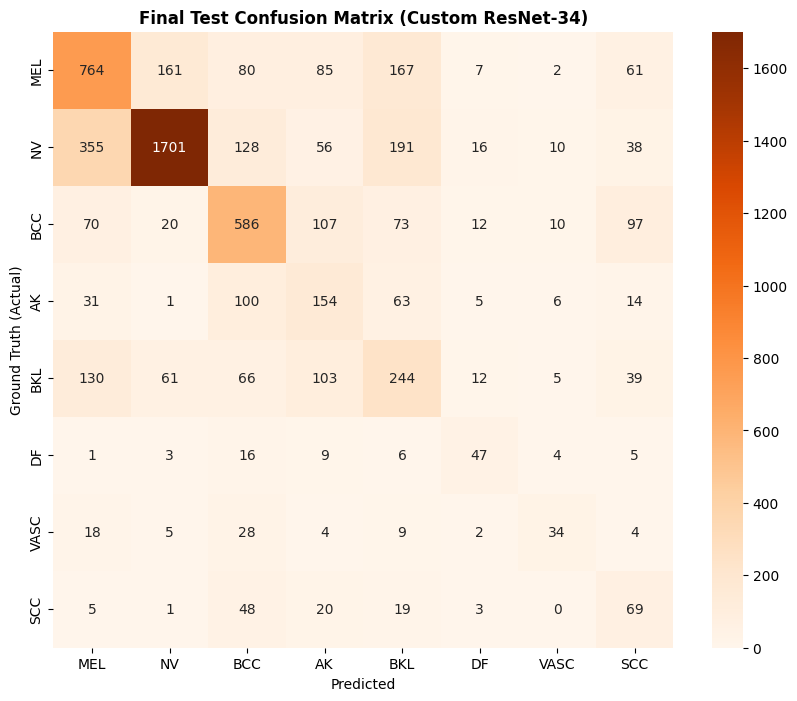

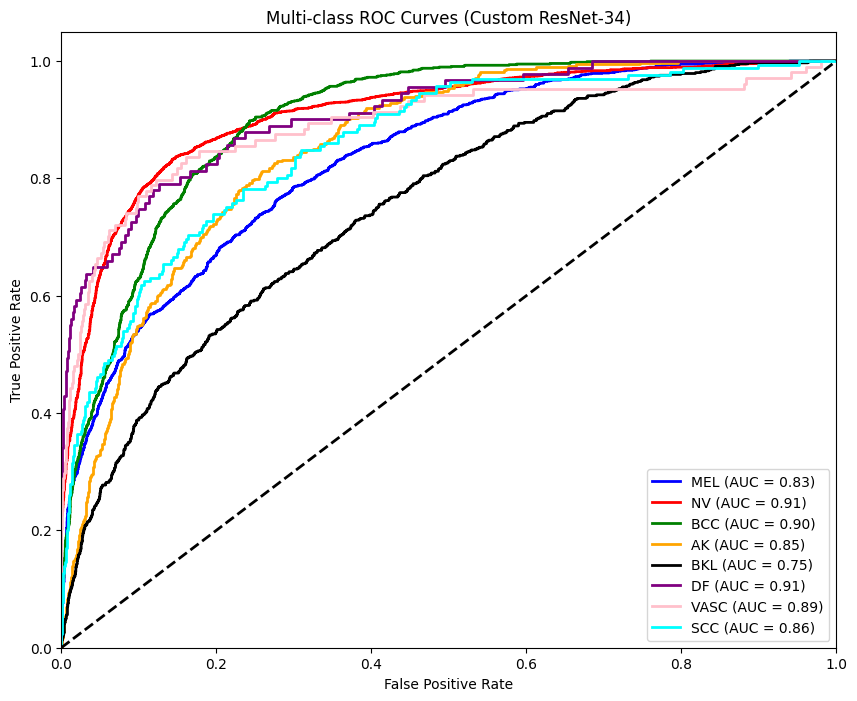

In [9]:
# EXPLICITLY LOAD THE BEST SCRATCH WEIGHTS
model_scratch34.load_state_dict(torch.load(model_save_path_scratch34, map_location=device, weights_only=True))
print(f"Successfully locked and loaded Custom ResNet-34 weights from: {model_save_path_scratch34}")

model_scratch34.eval()
y_true, y_probs = [], []

print("Running Comprehensive Evaluation on Test Set...")
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Inference"):
        imgs = imgs.to(device)
        outputs = model_scratch34(imgs)
        probs = torch.softmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = np.argmax(y_probs, axis=1)

y_true_bin = label_binarize(y_true, classes=[i for i in range(NUM_CLASSES)])
cm = confusion_matrix(y_true, y_pred)

def get_multi_metrics(conf_matrix):
    metrics_per_class = []
    for i in range(len(conf_matrix)):
        tp = conf_matrix[i, i]
        fn = sum(conf_matrix[i, :]) - tp
        fp = sum(conf_matrix[:, i]) - tp
        tn = sum(sum(conf_matrix)) - (tp + fp + fn)
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        metrics_per_class.append((sens, spec, prec))
    return np.mean(metrics_per_class, axis=0)

avg_sens, avg_spec, avg_prec = get_multi_metrics(cm)

print("FINAL PERFORMANCE REPORT:CUSTOM RESNET-34 (FROM SCRATCH)")
print("="*65)
print(f"Overall Accuracy:            {accuracy_score(y_true, y_pred):.4f}")
print(f"Balanced Accuracy:           {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"Precision (Weighted Avg):    {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall (Weighted Avg):       {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
# ---> HERE IS THE MISSING LINE <---
print(f"Sensitivity (Macro Avg):     {avg_sens:.4f}")
print(f"Specificity (Macro Avg):     {avg_spec:.4f}")
print(f"F1-Score (Weighted Avg):     {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Cohen's Kappa:               {cohen_kappa_score(y_true, y_pred):.4f}")

try:
    roc_auc_val = roc_auc_score(y_true_bin, y_probs, multi_class='ovr', average='macro')
    print(f"ROC-AUC Score (Macro OVR):   {roc_auc_val:.4f}")
except ValueError:
    print("ROC-AUC Score (Macro OVR):   N/A")
print("="*65)

print("\nDETAILED CLASSIFICATION REPORT (Per-Disease Breakdown):")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
print("="*65)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Final Test Confusion Matrix (Custom ResNet-34)', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Ground Truth (Actual)')
plt.show()



plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'black', 'purple', 'pink', 'cyan'])
for i, color in zip(range(NUM_CLASSES), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves (Custom ResNet-34)')
plt.legend(loc="lower right")
plt.show()